# Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, classification_report
import random
import math
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm

SEED = 1

random.seed(SEED)
np.random.seed(SEED)

# Load Data

In [ ]:
var_y = pd.read_csv('var_y.csv')
df = pd.read_csv('df.csv')

In [ ]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [ ]:
df.head()

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3


# Analysis

Populasi Total B28 Data Science Kemanggisan (Lokasi: G. Anggrek): 167 mahasiswa

Populasi tiap Kelas (strata):
- LA09: 34 mahasiswa
- LB09: 35 mahasiswa
- LC09: 32 mahasiswa
- LD09: 32 mahasiswa
- LE09: 34 mahasiswa

Weight Per Kelas Lab (sebelum data collection):
- 0.20
- 0.21
- 0.19
- 0.19
- 0.20

Revisi Perhitungan Awal
$$n_0 = \frac{Z^2 \cdot p(1-p)}{e^2}$$

$$ = \frac{(1.96)^2 \times 0.5 \times 0.5}{(0.10)^2} = \frac{3.8416 \times 0.25}{0.01} = \frac{0.9604}{0.01} = 96.04$$

Menyesuaikan dengan Jumlah Populasi Angkatan
$$n = \frac{n_0}{1 + \dfrac{n_0 - 1}{N}}$$

$$ = \frac{96.04}{1 + \dfrac{95.04}{167}} = \frac{96.04}{1.5691} = 61.2 \approx \textbf{62 responden}$$

Weighting per kelas
$$n_h = \frac{N_h}{N} \times n = \frac{N_h}{167} \times 62$$

In [ ]:
sample_needed = {}

populasi = {
    'LA09': 34, 'LB09': 35, 'LC09': 32,
    'LD09': 32, 'LE09': 34
}

for name, val in populasi.items():
    sample_needed[name] = math.ceil(val / 167 * 62)

print(sample_needed)

{'LA09': 13, 'LB09': 13, 'LC09': 12, 'LD09': 12, 'LE09': 13}


In [ ]:
sample_get = df['Kelas'].value_counts().sort_index().to_dict()
print(sample_get)

{'LA09': 14, 'LB09': 21, 'LC09': 10, 'LD09': 4, 'LE09': 7}


$$w_h = \frac{P_h}{f_h} = \frac{N_h/N}{n_h/n} = \frac{N_h}{N} \times \frac{n}{n_h}$$

In [ ]:
weight = {}

n = sum(sample_get.values())

for kelas in populasi:
    weight[kelas] = round((populasi[kelas] / 167) / (sample_get[kelas] / n), 4)
    
print(weight)

{'LA09': 0.8144, 'LB09': 0.5589, 'LC09': 1.0731, 'LD09': 2.6826, 'LE09': 1.6287}


In [ ]:
print(var_y.shape)
var_y.info()

(56, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y1      56 non-null     int64
 1   Y2      56 non-null     int64
 2   Y3      56 non-null     int64
 3   Y4      56 non-null     int64
 4   Y5      56 non-null     int64
 5   Y6      56 non-null     int64
 6   Y7      56 non-null     int64
 7   Y8      56 non-null     int64
 8   Y9      56 non-null     int64
 9   Y10     56 non-null     int64
 10  Y11     56 non-null     int64
 11  Y12     56 non-null     int64
 12  Y13     56 non-null     int64
 13  Y14     56 non-null     int64
 14  Y15     56 non-null     int64
 15  Y16     56 non-null     int64
 16  Y17     56 non-null     int64
 17  Y18     56 non-null     int64
 18  Y19     56 non-null     int64
 19  Y20     56 non-null     int64
dtypes: int64(20)
memory usage: 8.9 KB


In [ ]:
print(df.shape)
df.info()

(56, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Kelas   56 non-null     object
 1   Gender  56 non-null     object
 2   X1      56 non-null     int64 
 3   X2      56 non-null     int64 
 4   X3      56 non-null     int64 
 5   X4      56 non-null     int64 
 6   X5      56 non-null     int64 
 7   X6      56 non-null     int64 
 8   X7      56 non-null     int64 
 9   X8      56 non-null     int64 
 10  X9      56 non-null     int64 
 11  X10     56 non-null     int64 
dtypes: int64(10), object(2)
memory usage: 5.4+ KB


In [ ]:
df[['Kelas', 'Gender']].value_counts().sort_index()

Kelas  Gender
LA09   Pria       8
       Wanita     6
LB09   Pria      14
       Wanita     7
LC09   Pria      10
LD09   Pria       3
       Wanita     1
LE09   Pria       6
       Wanita     1
Name: count, dtype: int64

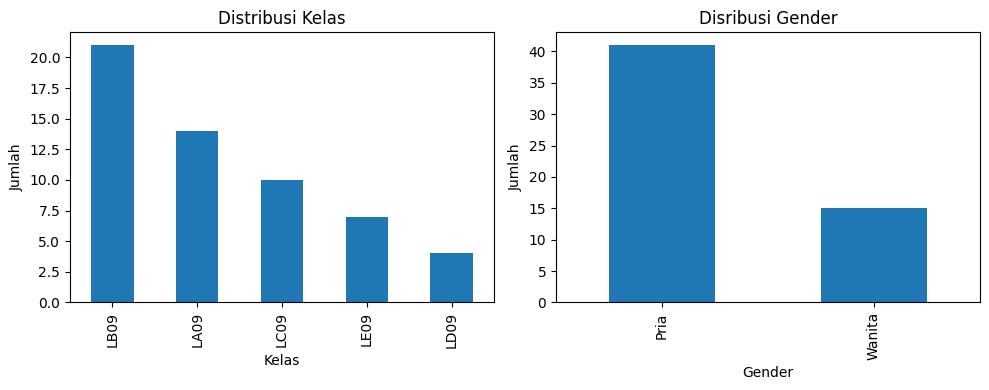

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

df['Kelas'].value_counts().plot(kind = 'bar', ax = ax[0])
ax[0].set_title('Distribusi Kelas')
ax[0].set_xlabel('Kelas')
ax[0].set_ylabel('Jumlah')

df['Gender'].value_counts().plot(kind = 'bar', ax = ax[1])
ax[1].set_xlabel('Gender')
ax[1].set_title('Disribusi Gender')
ax[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

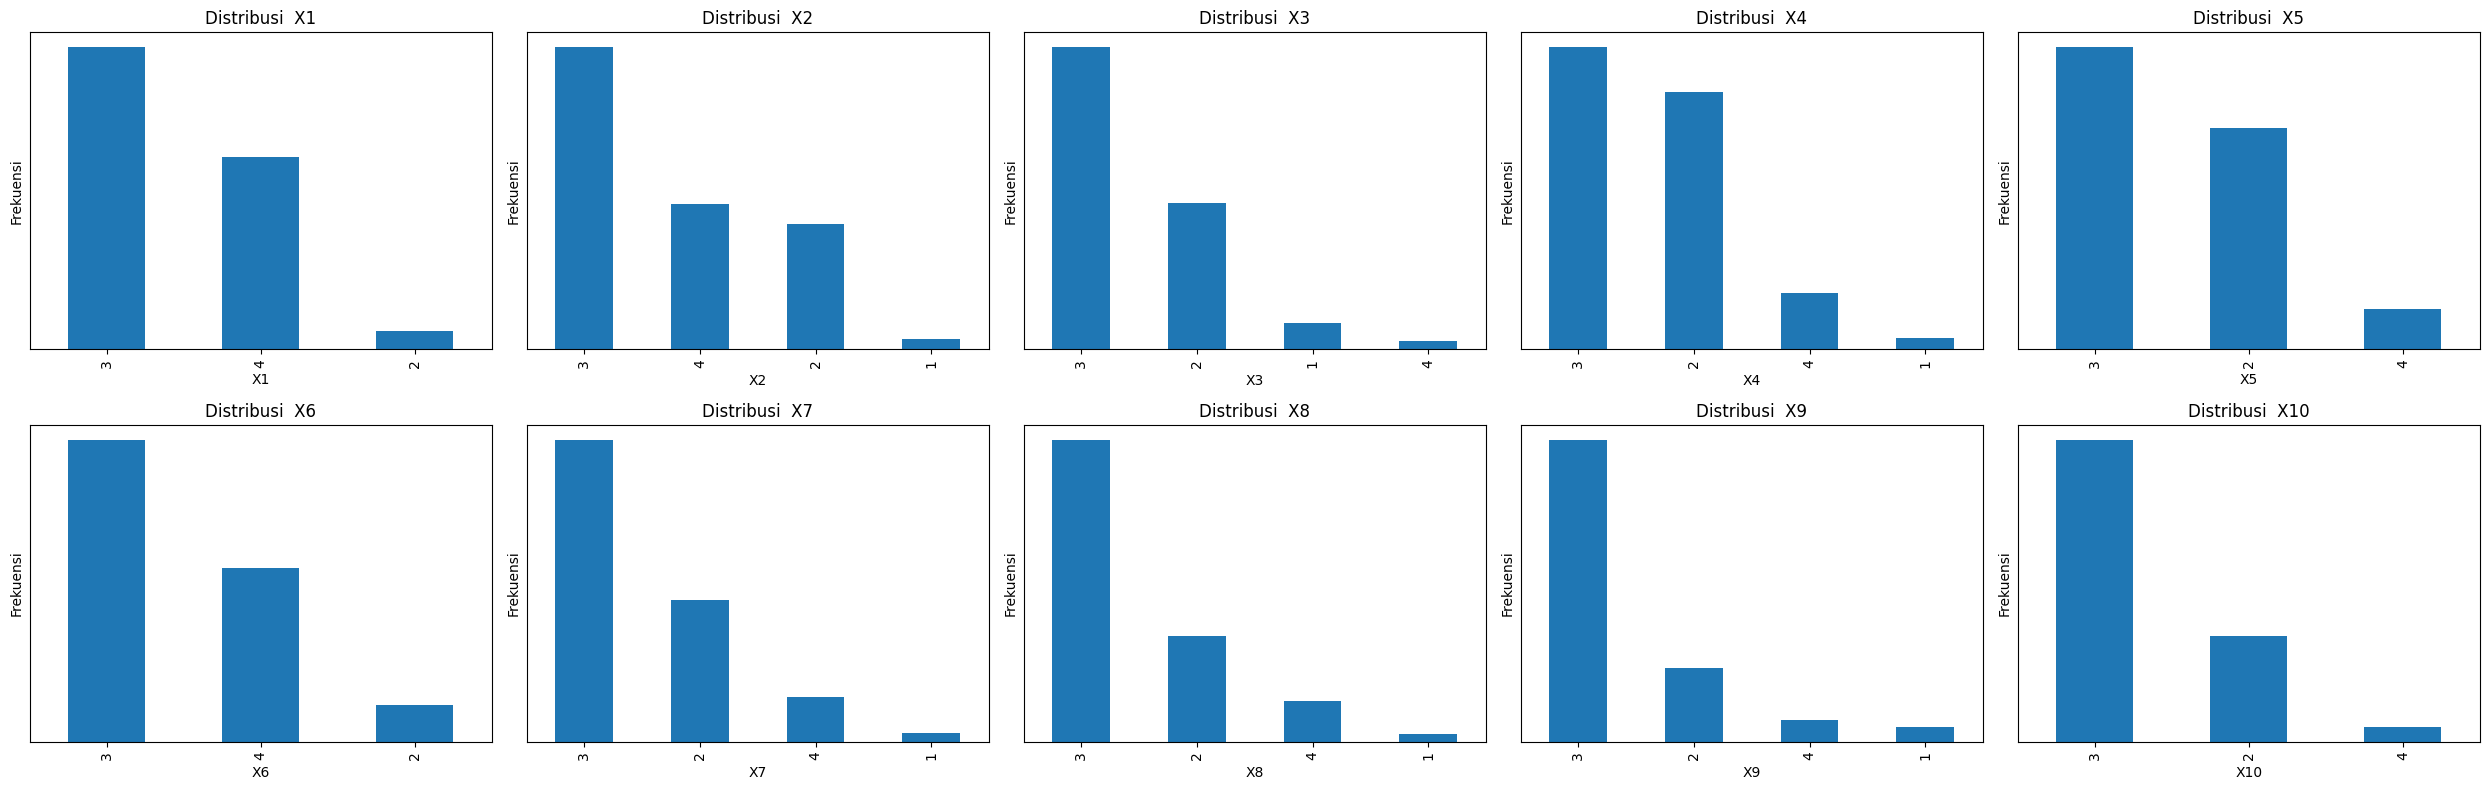

In [ ]:
var_x = df.iloc[:, 2:]

fig, ax = plt.subplots(2, 5, figsize=(25, 8))

ax = ax.flatten()

for i, col in enumerate(var_x.columns):
    var_x[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

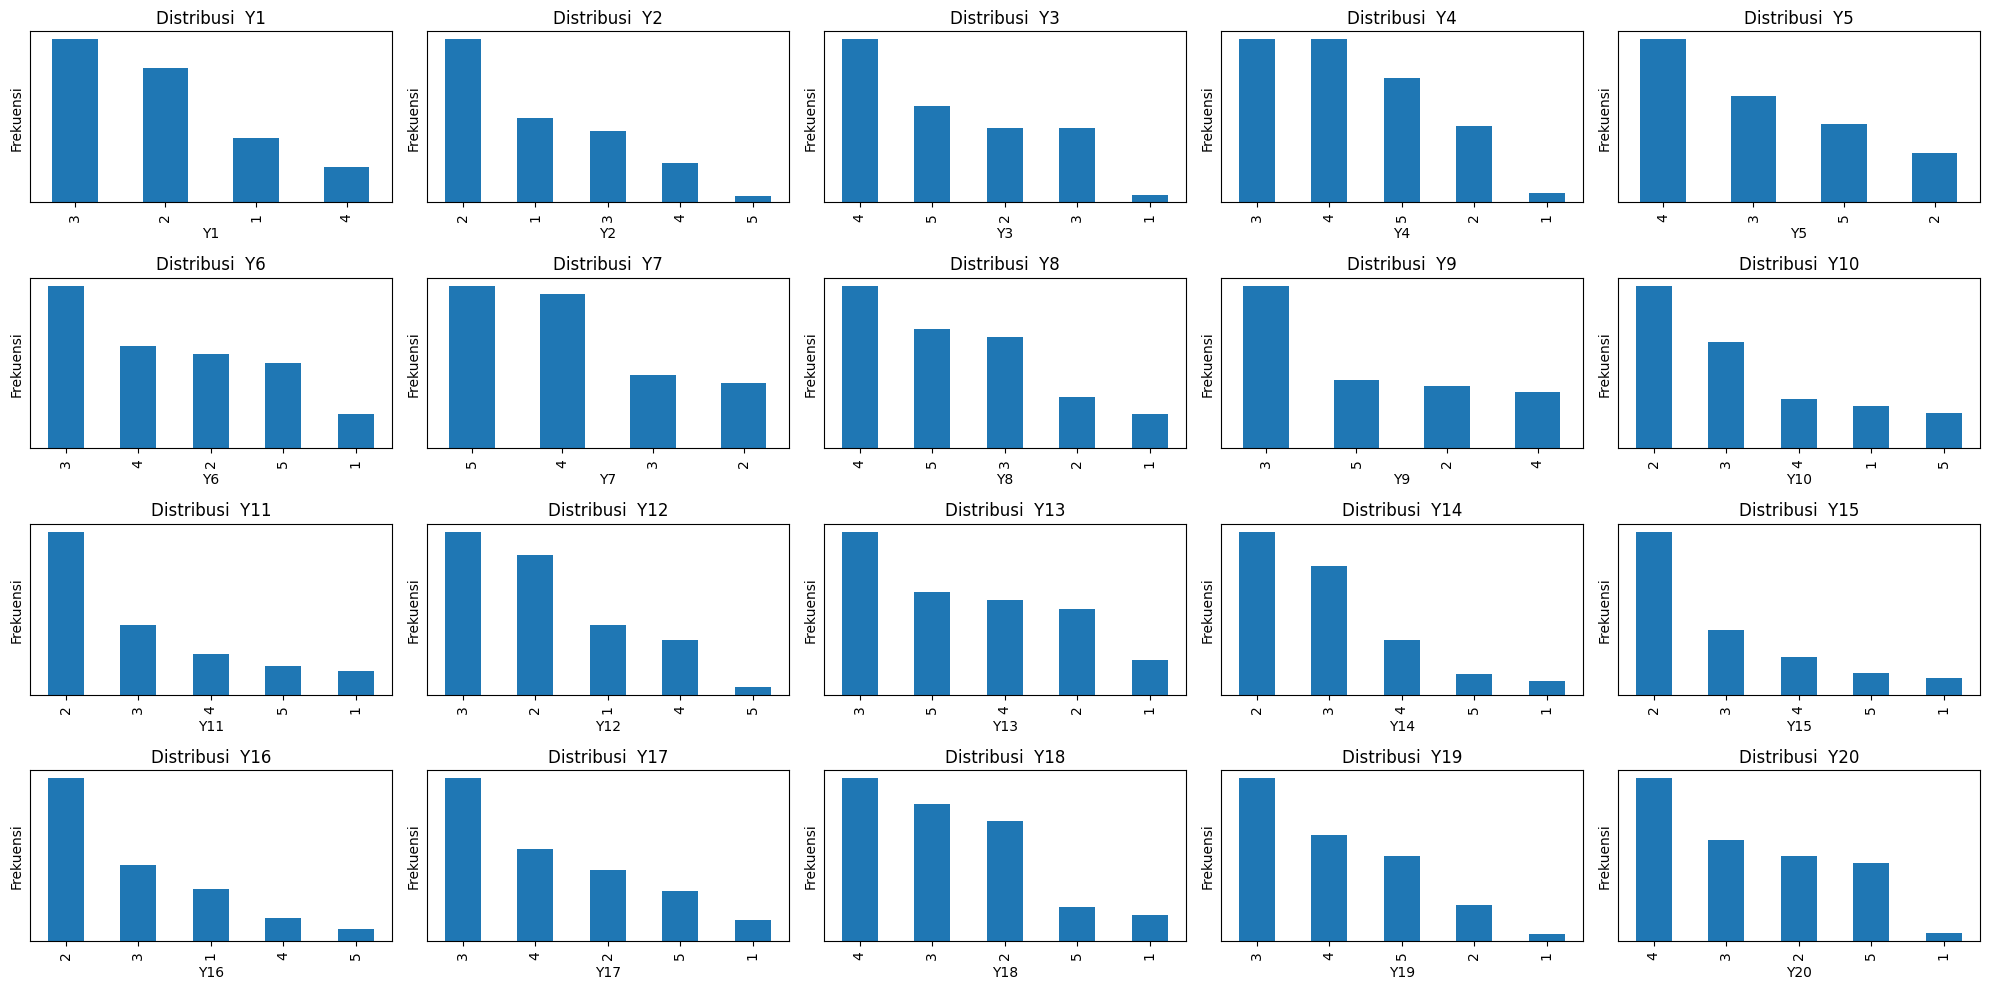

In [ ]:
fig, ax = plt.subplots(4, 5, figsize=(20, 10))

ax = ax.flatten()

for i, col in enumerate(var_y.columns[:20]):
    var_y[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

# Feature Engineering

In [ ]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [ ]:
var_y_scaled = MinMaxScaler().fit_transform(var_y)

In [ ]:
var_y_scaled

array([[0.33333333, 1.        , 1.        , ..., 0.75      , 0.5       ,
        1.        ],
       [0.33333333, 0.25      , 0.75      , ..., 0.75      , 1.        ,
        1.        ],
       [0.66666667, 0.25      , 1.        , ..., 0.5       , 0.5       ,
        0.25      ],
       ...,
       [0.33333333, 0.        , 0.75      , ..., 0.75      , 0.5       ,
        0.25      ],
       [0.        , 0.        , 0.25      , ..., 0.75      , 0.5       ,
        0.5       ],
       [0.33333333, 0.25      , 1.        , ..., 1.        , 1.        ,
        1.        ]])

# Modeling

## Regression

In [ ]:
df['target'] = var_y.sum(axis = 1) / 20

In [ ]:
df['target'].head(10)

0    4.05
1    3.45
2    3.25
3    3.25
4    2.55
5    3.00
6    3.50
7    3.00
8    3.55
9    3.15
Name: target, dtype: float64

In [ ]:
df['weight'] = df['Kelas'].map(weight)

In [ ]:
x = df.drop(columns=['target'])
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=SEED)

print(x_train.shape)
print(x_test.shape)

(47, 13)
(9, 13)


In [ ]:
lr = LinearRegression()

ohe_col = ['Gender', 'Kelas']
other_col = x.drop(columns = ohe_col + ['weight']).columns

prep = ColumnTransformer([
    ('ohe', OneHotEncoder(), ohe_col),
    ('other', 'passthrough', other_col)
])

lr_pipeline = Pipeline([
    ('preprocessor', prep),
    ('lr', lr)
])

lr_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10'], dtype='object'))])),
                ('lr', LinearRegression())])

### Evaluasi Regression

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# prediksi
y_pred_train = lr_pipeline.predict(x_train)
y_pred_test = lr_pipeline.predict(x_test)

# train metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# test metrics
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("=== TRAIN ===")
print("MAE  :", mae_train)
print("MSE  :", mse_train)
print("RMSE :", rmse_train)
print("R2   :", r2_train)

print("\n=== TEST ===")
print("MAE  :", mae_test)
print("MSE  :", mse_test)
print("RMSE :", rmse_test)
print("R2   :", r2_test)

=== TRAIN ===
MAE  : 0.29770057155502067
MSE  : 0.1678837604807287
RMSE : 0.40973620840820096
R2   : 0.2527599699739481

=== TEST ===
MAE  : 0.30226646554791636
MSE  : 0.1323287568200535
RMSE : 0.3637701978173219
R2   : 0.5309133784497011


### Interpretasi Model Regression

In [ ]:
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

coef = lr_pipeline.named_steps['lr'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef*100
})

coef_df.head(20)

,Feature,Coefficient
0,ohe__Gender_Pria,-7.231540
1,ohe__Gender_Wanita,7.231540
2,ohe__Kelas_LA09,9.817505
3,ohe__Kelas_LB09,6.282196
4,ohe__Kelas_LC09,11.086656
5,ohe__Kelas_LD09,-15.895658
6,ohe__Kelas_LE09,-11.290699
7,other__X1,29.560293
8,other__X2,-5.340749
9,other__X3,-15.380476


### Repair data

In [ ]:
df = df.drop(columns='target')

In [ ]:
df.columns

Index(['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'weight'],
      dtype='object')

## Clustering

In [ ]:
kmeans_scaled = KMeans(n_clusters = 4, random_state=SEED)
kmeans_scaled.fit(var_y_scaled)

KMeans(n_clusters=4, random_state=1)

In [ ]:
kmeans = KMeans(n_clusters = 4, random_state=SEED)
kmeans.fit(var_y)

KMeans(n_clusters=4, random_state=1)

In [ ]:
pred = kmeans.predict(var_y)
pred_scaled = kmeans_scaled.predict(var_y_scaled)

In [ ]:
temp = var_y.copy()

temp['target_raw'] = pred
temp['target_scaled'] = pred_scaled

temp.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,...,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20,target_raw,target_scaled
0,2,5,5,5,4,5,5,5,5,3,...,5,4,4,2,5,4,3,5,3,3
1,2,2,4,3,4,2,4,4,4,3,...,4,2,2,2,5,4,5,5,1,1
2,3,2,5,4,2,3,4,5,3,3,...,4,3,3,2,3,3,3,2,1,1
3,2,3,4,4,3,3,4,2,2,3,...,3,4,4,2,3,3,4,3,1,0
4,1,1,2,3,3,3,4,3,3,4,...,2,3,3,2,1,4,4,1,0,0


In [ ]:
# var_y.head()

In [ ]:
raw = var_y.copy()

raw['result'] = pred

profile_raw = raw.groupby(['result']).mean()

profile_raw

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
result,,,,,,,,,,,,,,,,,,,,
0,1.866667,1.933333,2.533333,2.600000,3.000000,3.466667,4.600000,3.200000,3.266667,2.866667,2.800000,1.800000,2.466667,2.600000,2.600000,2.133333,2.266667,2.333333,3.266667,2.533333
1,2.363636,1.818182,4.363636,3.727273,3.818182,3.181818,3.909091,3.363636,3.545455,2.818182,3.363636,3.181818,3.818182,2.727273,2.454545,2.000000,3.272727,2.909091,3.636364,3.272727
2,2.722222,2.388889,3.944444,3.555556,3.666667,2.333333,2.833333,3.388889,2.944444,1.944444,1.944444,2.666667,2.944444,2.333333,2.055556,2.333333,3.166667,3.333333,3.388889,3.777778
3,2.750000,2.750000,3.916667,4.750000,4.416667,4.333333,4.666667,4.583333,4.000000,3.416667,2.916667,2.583333,4.416667,3.583333,3.666667,2.833333,4.333333,4.000000,4.166667,4.500000


In [ ]:
scaled = var_y.copy()

scaled['result'] = pred_scaled

profile_scaled = scaled.groupby(['result']).mean()

profile_scaled

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
result,,,,,,,,,,,,,,,,,,,,
0,1.823529,1.882353,2.823529,2.588235,3.117647,3.235294,4.588235,3.000000,3.000000,2.705882,2.882353,2.058824,2.529412,2.705882,2.647059,2.058824,2.294118,2.352941,3.470588,2.647059
1,2.625000,2.208333,4.125000,3.583333,3.666667,2.625000,3.041667,3.458333,3.250000,2.083333,2.291667,2.791667,3.208333,2.375000,2.083333,2.250000,3.250000,3.291667,3.458333,3.583333
2,3.125000,2.625000,3.375000,4.625000,4.125000,4.125000,4.125000,4.250000,3.875000,4.125000,3.125000,2.875000,3.875000,3.375000,3.500000,3.250000,3.500000,3.375000,3.500000,4.000000
3,2.428571,2.714286,4.285714,4.857143,4.571429,4.285714,5.000000,4.714286,4.142857,3.000000,2.857143,2.285714,4.857143,3.428571,3.428571,2.142857,4.857143,4.142857,4.285714,4.714286


In [ ]:
y_cols = var_y.columns.tolist()

In [ ]:
mean_pre_cluster_raw = temp.groupby('target_raw')[y_cols].mean().mean(axis=1)
stress_map_raw = mean_pre_cluster_raw.rank().astype(int).to_dict()

temp['stress_level_raw'] = temp['target_raw'].map(stress_map_raw)

print("Variabel Y Raw")
pd.DataFrame({
    'mean': mean_pre_cluster_raw,
    'stress_level_raw': stress_map_raw
}).sort_values('stress_level_raw')

Variabel Y Raw


,mean,stress_level_raw
0,2.706667,1
2,2.883333,2
1,3.177273,3
3,3.829167,4


In [ ]:
mean_pre_cluster_scaled = temp.groupby('target_scaled')[y_cols].mean().mean(axis = 1)
stress_map_scaled = mean_pre_cluster_scaled.rank().astype(int).to_dict()

temp['stress_level_scaled'] = temp['target_scaled'].map(stress_map_scaled)

print("Variabel Y Scaled")
pd.DataFrame({
    'mean': mean_pre_cluster_scaled,
    'stress_level_scaled': stress_map_scaled
}).sort_values('stress_level_scaled')

Variabel Y Scaled


,mean,stress_level_scaled
0,2.720588,1
1,2.962500,2
2,3.637500,3
3,3.850000,4


### Evaluasi Model Clustering

In [ ]:
print("Clustering Variabel Y Raw")
print("="*45)
print("Silhouette Score:", silhouette_score(var_y, pred))
print("Davies Bouldin Score:", davies_bouldin_score(var_y, pred))
print("Calinski Harabasz Score:", calinski_harabasz_score(var_y, pred))

print("="*45, "\n")

print("CLustering Variabel Y Scaled")
print("="*45)
print("Silhouette Score:", silhouette_score(var_y_scaled, pred_scaled))
print("Davies Bouldin Score:", davies_bouldin_score(var_y_scaled, pred_scaled))
print("Calinski Harabasz Score:", calinski_harabasz_score(var_y_scaled, pred_scaled))
print("="*45)

Clustering Variabel Y Raw
Silhouette Score: 0.07627977763282145
Davies Bouldin Score: 2.2553898744637353
Calinski Harabasz Score: 7.744557507220933

CLustering Variabel Y Scaled
Silhouette Score: 0.10097235549656507
Davies Bouldin Score: 2.2404697799758235
Calinski Harabasz Score: 7.487861902806296


In [ ]:
# Sudah ada di notebookmu, tinggal rapikan:
results = {}
for k in range(2, 5):
    km = KMeans(n_clusters=k, random_state=SEED)
    labels = km.fit_predict(var_y)
    
    results[k] = {
        'silhouette': silhouette_score(var_y, labels),   # makin tinggi makin baik (max 1)
        'dbi':        davies_bouldin_score(var_y, labels), # makin rendah makin baik
        'ch':         calinski_harabasz_score(var_y, labels) # makin tinggi makin baik
    }

pd.DataFrame(results).T

,silhouette,dbi,ch
2,0.122373,2.276350,9.447239
3,0.107797,1.975026,9.125344
4,0.076280,2.255390,7.744558


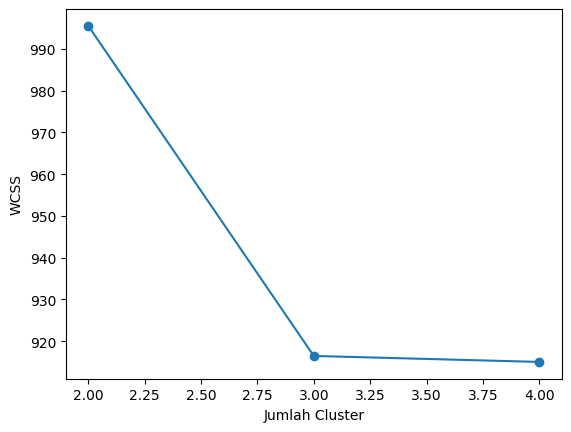

In [ ]:
wcss = []

for k in range(2,5):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(var_y)
    wcss.append(km.inertia_)

plt.plot(range(2,5), wcss, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()

## Data Setup

In [ ]:
temp.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,...,Y15,Y16,Y17,Y18,Y19,Y20,target_raw,target_scaled,stress_level_raw,stress_level_scaled
0,2,5,5,5,4,5,5,5,5,3,...,4,2,5,4,3,5,3,3,4,4
1,2,2,4,3,4,2,4,4,4,3,...,2,2,5,4,5,5,1,1,3,2
2,3,2,5,4,2,3,4,5,3,3,...,3,2,3,3,3,2,1,1,3,2
3,2,3,4,4,3,3,4,2,2,3,...,4,2,3,3,4,3,1,0,3,1
4,1,1,2,3,3,3,4,3,3,4,...,3,2,1,4,4,1,0,0,1,1


In [ ]:
df['target'] = temp['stress_level_scaled']

In [ ]:
df.head()

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,weight,target
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2,1.0731,4
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2,0.8144,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2,0.5589,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4,0.5589,1
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3,0.5589,1


## Classification

In [ ]:
weights = df['weight']

df = df.drop('weight', axis = 1)

x = df.drop('target', axis = 1)
y = df['target']

x_train, x_test, y_train, y_test, w_train, w_test = train_test_split(x, y, weights, test_size=0.2, stratify=y, random_state=SEED)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(44, 12)
(44,)
(12, 12)
(12,)
target
2    19
1    13
4     6
3     6
Name: count, dtype: int64
target
2    5
1    4
3    2
4    1
Name: count, dtype: int64


In [ ]:
m_logit = LogisticRegression(multi_class='multinomial', max_iter = 1000, penalty=None)

model = Pipeline([
    ('prep', prep),
    ('logit', m_logit)
])

model.fit(x_train, y_train, logit__sample_weight=w_train)

c:\Users\willi\anaconda3\envs\stats-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10'], dtype='object'))])),
                ('logit',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    penalty=None))])

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.67      1.00      0.80         4
           2       0.67      0.40      0.50         5
           3       0.33      0.50      0.40         2
           4       0.00      0.00      0.00         1

    accuracy                           0.58        12
   macro avg       0.42      0.47      0.43        12
weighted avg       0.56      0.58      0.54        12



c:\Users\willi\anaconda3\envs\stats-env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\willi\anaconda3\envs\stats-env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\willi\anaconda3\envs\stats-env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

In [ ]:
feature_names = model.named_steps['prep'].get_feature_names_out()

coef = model.named_steps['logit'].coef_

classes = model.named_steps['logit'].classes_

coef_df = pd.DataFrame(
    coef.T,
    columns=[f'{c}' for c in classes],
    index = feature_names
)

coef_df.head(20)

,1,2,3,4
ohe__Gender_Pria,28.258465,30.149178,-32.402887,-26.004755
ohe__Gender_Wanita,16.196492,15.324585,-36.984984,5.463907
ohe__Kelas_LA09,-29.107199,-8.334551,14.646190,22.795560
ohe__Kelas_LB09,2.756505,21.786765,-3.052702,-21.490568
ohe__Kelas_LC09,5.572697,28.355794,-35.139209,1.210719
ohe__Kelas_LD09,52.216347,-30.935147,-13.419281,-7.861918
ohe__Kelas_LE09,13.016608,34.600902,-32.422869,-15.194641
other__X1,-79.299579,-26.428724,57.583227,48.145076
other__X2,11.737474,11.897922,-81.718436,58.083040
other__X3,3.534138,3.005943,43.321277,-49.861357
